# Three Steps MultiFidelity Neural Network

In [21]:
#########################     LIBRARIES     ##########################
import keras.backend as K
from keras.callbacks import ModelCheckpoint
# import warnings
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from keras.models import save_model
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from ann_functions import getModel, kCrossVal, transfBestparam, import_data
from time import perf_counter
import pandas
import pickle
import os

seed = 7
np.random.seed(seed)

## Data preparation

In [22]:
Discretizations= np.loadtxt(
    "../DATA/Discretizations.txt"
).astype(
    int
)

diffusion= np.loadtxt(
    "../DATA/diffusion.txt"
).astype(
    int
)

In [23]:
#file_path_LF = "../DATA/reaction_diffusion_LF_28_d1.mat"
#(reaction_LF_test, U_LF_test) = import_data(file_path_LF)
file_path_HF = "../DATA/reaction_diffusion_HF.mat"
(reaction_HF_test, U_HF_test) = import_data(file_path_HF)

In [24]:
# NORMALIZATION

reaction_max = np.max(reaction_HF_test)
reaction_min = np.min(reaction_HF_test)

#reaction_LF_test = (reaction_LF_test - reaction_min) / (
#    reaction_max - reaction_min
#)
reaction_HF_test = (reaction_HF_test - reaction_min) / (
    reaction_max - reaction_min
)

In [25]:
# Output
# We consider the central value of U
#U_LF_test = U_LF_test[
#    :,
#    - 1,
#    12,12
#]

U_HF_test = U_HF_test[:, -1, 44,44]

U_h_max_test = np.max(U_HF_test)
U_h_min_test = np.min(U_HF_test)
#U_t_max_test = np.max(U_LF_test)
#U_t_min_test = np.min(U_LF_test)

#U_LF_test = (U_LF_test - U_t_min_test) / (U_t_max_test - U_t_min_test)
U_HF_test = (U_HF_test - U_h_min_test) / (U_h_max_test - U_h_min_test)

#permutation = np.random.permutation(len(reaction_LF_test))
#Nlf = 20
#reaction_LF = reaction_LF_test[permutation][0:Nlf]
#U_LF = U_LF_test[permutation][0:Nlf]

permutation = np.random.permutation(len(reaction_HF_test))
n_HF = 15
reaction_HF = reaction_HF_test[permutation][0:n_HF]
U_HF = U_HF_test[permutation][0:n_HF]


In [26]:
NepoLF = 5000  # number of epochs for first NN: NN_LF
NepoLin = 1500
NepoHF = 3000  # number of epochs for second NN: NN_HF 
Nlf=30

U_LF_list = []
U_Lin_list = []
U_HF_list = []
#HF_data = [10]
#HF_data_str = [str(num) for num in HF_data]
r2_HF_df = pandas.DataFrame(columns=['Discretization','Diffusion','R2'])  # dataframe which stores HF R^2
r2_LF_df = pandas.DataFrame(columns=['Discretization','Diffusion','R2'])  # dataframe which stores LF R^2
r2_Lin_df = pandas.DataFrame(columns=['Discretization','Diffusion','R2'])
mse_HF_df = pandas.DataFrame(columns=['Discretization','Diffusion','MSE'])  # dataframe which stores HF MSE
mse_LF_df = pandas.DataFrame(columns=['Discretization','Diffusion','MSE'])  # dataframe which stores LF MSE
mse_Lin_df = pandas.DataFrame(columns=['Discretization','Diffusion','MSE'])


## Neural Network
Cycle on the Discretization and the value of the diffusion

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 0  ********************
LF NN done
2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.12700912111971613
R^2: -0.018753749851393442
2/2 [==============================] - 0s 0s/step
Elapsed time:  23.08386780001456
2/2 [==============================] - 0s 16ms/step

Lin Model:
Test MSE: 0.11993054961427188
R^2: -0.05946850490101063

HF Model:
Test MSE: 0.12698565009057045
R^2: -0.12179338190349998
2/2 [==============================] - 0s 0s/step


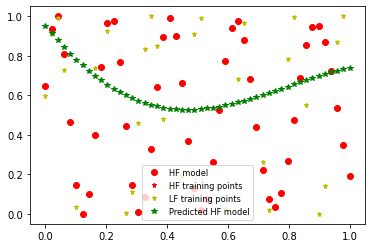

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:215: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:217: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:219: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_Lin_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:221: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df.append(new, ignore_index=True)
C:\Users\Giaco

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 5  ********************
LF NN done
2/2 [==============================] - 0s 13ms/step

LF Model:
Test MSE: 0.007154464505127096
R^2: 0.9424935721225786
2/2 [==============================] - 0s 0s/step
Elapsed time:  23.498459599970374
2/2 [==============================] - 0s 18ms/step

Lin Model:
Test MSE: 0.12186077006063323
R^2: -0.07652010498967132

HF Model:
Test MSE: 0.206190767874296
R^2: -0.8214927328088855
2/2 [==============================] - 0s 0s/step


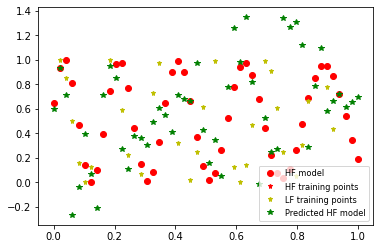

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:215: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:217: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:219: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_Lin_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:221: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df.append(new, ignore_index=True)
C:\Users\Giaco

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 75  ********************
LF NN done
2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.1302801471518752
R^2: -0.02121432524346112
2/2 [==============================] - 0s 0s/step
Elapsed time:  24.683779900020454
2/2 [==============================] - 0s 2ms/step

Lin Model:
Test MSE: 0.11993155385488846
R^2: -0.05947737637961259

HF Model:
Test MSE: 0.127057032068348
R^2: -0.1224239715031985
2/2 [==============================] - 0s 7ms/step


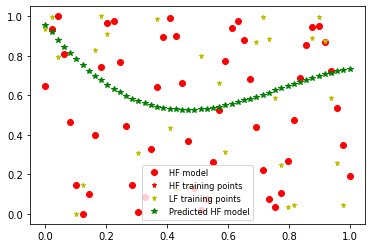

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:215: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:217: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:219: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_Lin_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:221: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df.append(new, ignore_index=True)
C:\Users\Giaco

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 1  ********************
LF NN done
2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.09968743677700827
R^2: 0.1794827956764633
2/2 [==============================] - 0s 0s/step
Elapsed time:  22.701787300000433
2/2 [==============================] - 0s 3ms/step

Lin Model:
Test MSE: 0.10630694039551107
R^2: 0.060882689492569364

HF Model:
Test MSE: 0.11045411491076189
R^2: 0.024246479641384933
2/2 [==============================] - 0s 2ms/step


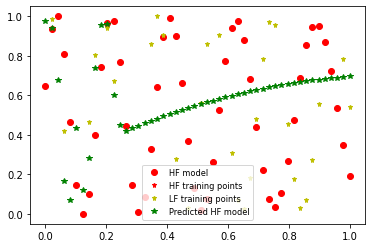

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:215: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:217: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:219: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_Lin_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:221: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df.append(new, ignore_index=True)
C:\Users\Giaco

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 0  ********************
LF NN done
2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.10283870830987399
R^2: 0.17485070304293981
2/2 [==============================] - 0s 1ms/step
Elapsed time:  23.41320289997384
2/2 [==============================] - 0s 0s/step

Lin Model:
Test MSE: 0.11936671565903799
R^2: -0.0544875861986005

HF Model:
Test MSE: 0.11933058627210069
R^2: -0.05416841858297161
2/2 [==============================] - 0s 5ms/step


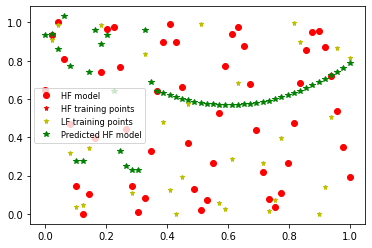

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:215: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:217: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:219: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_Lin_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:221: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df.append(new, ignore_index=True)
C:\Users\Giaco

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 5  ********************
LF NN done
2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.0023019554661254356
R^2: 0.9796750221015192
2/2 [==============================] - 0s 0s/step
Elapsed time:  22.439469199976884
2/2 [==============================] - 0s 0s/step

Lin Model:
Test MSE: 0.008434762438796855
R^2: 0.925487165872507

HF Model:
Test MSE: 0.008295905421856405
R^2: 0.9267138311100639
2/2 [==============================] - 0s 5ms/step


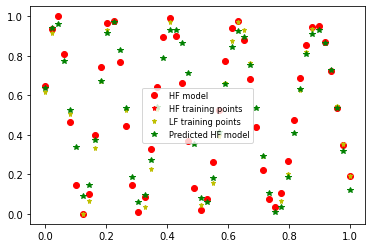

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:215: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:217: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:219: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_Lin_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:221: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df.append(new, ignore_index=True)
C:\Users\Giaco

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 75  ********************
LF NN done
2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.0023492202247578134
R^2: 0.9800196752621059
2/2 [==============================] - 0s 0s/step
Elapsed time:  22.552015000022948
2/2 [==============================] - 0s 0s/step

Lin Model:
Test MSE: 0.07437313551665536
R^2: 0.342986462214509

HF Model:
Test MSE: 0.3177766261716608
R^2: -1.8072440933974692
2/2 [==============================] - 0s 0s/step


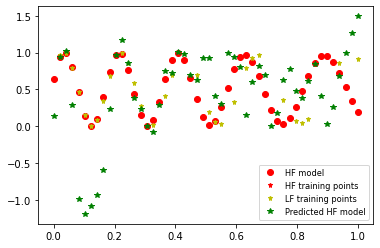

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:215: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:217: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:219: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_Lin_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:221: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df.append(new, ignore_index=True)
C:\Users\Giaco

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 1  ********************
LF NN done
2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.0019235678138157656
R^2: 0.9837325100311387
2/2 [==============================] - 0s 3ms/step
Elapsed time:  22.82931510003982
2/2 [==============================] - 0s 0s/step

Lin Model:
Test MSE: 0.07860804341892051
R^2: 0.3055752141377105

HF Model:
Test MSE: 0.1117852789082403
R^2: 0.012486954360107605
2/2 [==============================] - 0s 17ms/step


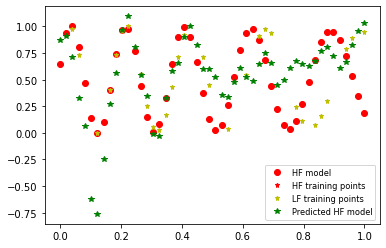

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:215: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:217: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:219: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_Lin_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:221: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df.append(new, ignore_index=True)
C:\Users\Giaco

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 0  ********************
LF NN done
2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.12459146084687481
R^2: -7.453368833432172e-05
2/2 [==============================] - 0s 17ms/step
Elapsed time:  22.57177340000635
2/2 [==============================] - 0s 17ms/step

Lin Model:
Test MSE: 0.11993431950281956
R^2: -0.05950180816023942

HF Model:
Test MSE: 0.12709558999459428
R^2: -0.12276459287618158
2/2 [==============================] - 0s 0s/step


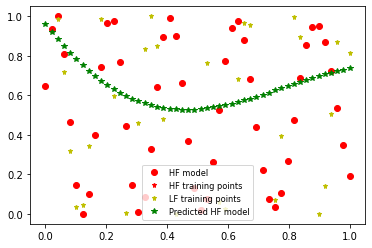

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:215: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:217: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:219: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_Lin_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:221: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df.append(new, ignore_index=True)
C:\Users\Giaco

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 5  ********************
LF NN done
2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.11379144586548355
R^2: -0.00026215831290166136
2/2 [==============================] - 0s 4ms/step
Elapsed time:  22.719542299979366
2/2 [==============================] - 0s 3ms/step

Lin Model:
Test MSE: 0.11992822679612329
R^2: -0.05944798508617666

HF Model:
Test MSE: 0.1271188415956984
R^2: -0.12296999791382657
2/2 [==============================] - 0s 0s/step


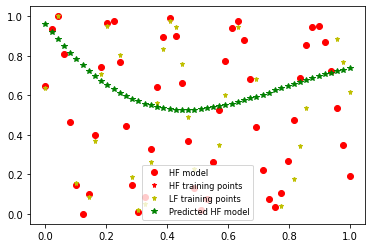

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:215: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:217: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:219: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_Lin_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:221: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df.append(new, ignore_index=True)
C:\Users\Giaco

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 75  ********************
LF NN done
2/2 [==============================] - 0s 3ms/step

LF Model:
Test MSE: 0.04040274295529966
R^2: 0.6569882009042147
2/2 [==============================] - 0s 0s/step
Elapsed time:  22.70187490002718
2/2 [==============================] - 0s 0s/step

Lin Model:
Test MSE: 0.04390372029201864
R^2: 0.6121537919489208

HF Model:
Test MSE: 0.08722365158094718
R^2: 0.22946478583071717
2/2 [==============================] - 0s 0s/step


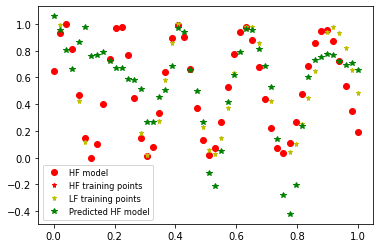

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:215: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:217: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:219: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_Lin_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:221: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df.append(new, ignore_index=True)
C:\Users\Giaco

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 1  ********************
LF NN done
2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.002774805287827245
R^2: 0.9760286240216831
2/2 [==============================] - 0s 0s/step
Elapsed time:  23.032284900022205
2/2 [==============================] - 0s 0s/step

Lin Model:
Test MSE: 0.013673649215437435
R^2: 0.8792067514289418

HF Model:
Test MSE: 0.014331611440331739
R^2: 0.8733943019993999
2/2 [==============================] - 0s 0s/step


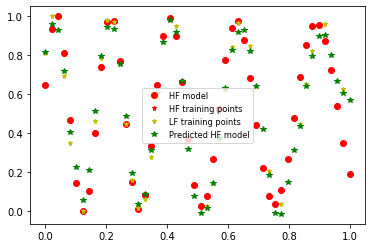

Empty DataFrame
Columns: [Discretization, Diffusion, R2]
Index: []
Empty DataFrame
Columns: [Discretization, Diffusion, MSE]
Index: []


C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:215: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:217: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:219: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_Lin_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10792\1842399101.py:221: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df.append(new, ignore_index=True)
C:\Users\Giaco

In [35]:
#checkpoint = ModelCheckpoint("best_model_3NN.h5", monitor="val_loss", save_best_only=True)
test_mse_HF_list = []
test_mse_LF_list = []
test_mse_Lin_list = []

r2_HF_list = []
r2_LF_list = []
r2_Lin_list = []

for m in range(len(Discretizations)):
    for d in range(len(diffusion)):    # Loop over the range of the number of basis functions
        file_path_LF = "../DATA/reaction_diffusion_LF_"+str(Discretizations[m])+"_d"+str(diffusion[d])+".mat"
        (reaction_LF_test, U_LF_test) = import_data(file_path_LF)
        
        reaction_max = np.max(reaction_LF_test)
        reaction_min = np.min(reaction_LF_test)
        reaction_LF_test = (reaction_LF_test - reaction_min) / (
            reaction_max - reaction_min
        )
        
        permutation = np.random.permutation(len(reaction_LF_test))
        reaction_LF = reaction_LF_test[permutation][0:Nlf]
        U_LF_test = U_LF_test[
        :,
        - 1,
        int(4*(Discretizations[m]-1)/9),
        int(4*(Discretizations[m]-1)/9)
        ]
        U_t_max_test = np.max(U_LF_test)
        U_t_min_test = np.min(U_LF_test)
        
        U_LF_test = (U_LF_test - U_t_min_test) / (U_t_max_test - U_t_min_test)
       

        U_train_LF = U_LF_test[permutation][0:Nlf]


        print(
        f"********************  # Nb. nodes = {Discretizations[m]}  ********************"
        )
        
        print(
        f"********************  # Diff: = {diffusion[d]}  ********************"
        )
 

       ##########################       FIRST NN: NN_LF     ##########################
        K.clear_session()
        bestLF_params = {
            "lr": 0.0255,
            "kernel_init": "glorot_uniform",
            "opt": "Adam",
        }

        modelLF = getModel(bestLF_params, "LF")

        histLF = modelLF.fit(
            reaction_LF, U_train_LF, epochs=NepoLF, batch_size=Nlf, verbose=0
        )
        print("LF NN done")

        ULF = modelLF.predict(reaction_LF_test)
        U_LF_list.append(ULF)
        print("\nLF Model:")

        test_mse = np.mean(np.square(U_LF_test - ULF[:, 0]))
        test_mse_LF_list.append(test_mse)
        print(f"Test MSE: {test_mse}")

        r_2 = 1 - np.sum(np.square(U_LF_test - ULF[:, 0])) / np.sum(
            np.square(U_LF_test - np.mean(U_LF_test))
        )
        r2_LF_list.append(r_2)
        print(f"R^2: {r_2}")

        start = perf_counter()
        ##########################    SECOND NN: NN_Lin    ##########################
        reaction_test_help = modelLF.predict(reaction_HF_test)[:, 0]
        reaction_test_in = np.vstack(
            (reaction_HF_test[:, 0], reaction_test_help)
        ).transpose()  # <- TEST INPUT for the second NN: NN_Lin

        reaction_train_help = modelLF.predict(reaction_HF)[
            :, 0
        ]  # f_LF(mu_hf_train)
        reaction_lin = np.vstack(
            (reaction_HF[:, 0], reaction_train_help)
        ).transpose()  # <- TRAINING INPUT for the second NN: NN_Lin

        bestLin_params = {
            "lr": 0.001,
            "kernel_init": "glorot_uniform",
            "opt": "Adam",
            "l2weight": 0.01,
        }
        modelLin = getModel(bestLin_params, "Hflin")
        histLin = modelLin.fit(
            reaction_lin,
            U_HF,
            validation_data=(reaction_test_in, U_HF_test),
            epochs=NepoLin,
            batch_size=n_HF,
            verbose=0,
            validation_freq=50,
        )

        ULin = modelLin.predict(
            np.vstack((reaction_HF_test[:, 0], reaction_test_help)).transpose()
        )

        ##########################    THIRD NN: NN_HF    ##########################
        # Input for training NN_HF
        reaction_help1 = modelLin.predict(reaction_lin)[:, 0]
        reaction_final = np.vstack(
            (reaction_HF[:, 0], reaction_train_help, reaction_help1)
        ).transpose()

        # Input for testing NN_HF
        reaction_test_help1 = modelLin.predict(reaction_test_in)[:, 0]
        reaction_test_final = np.vstack(
            (reaction_HF_test[:, 0], reaction_test_help, reaction_test_help1)
        ).transpose()

        name = "3step"
        MAX_EVAL = 15

        K.clear_session()
        # best paramters obtained by HPO:
        
        best_params={'kernel_init': 'glorot_uniform', 'l2weight': 0.0001933368067753076, 'lr': 0.004404993622688278, 'nodes': 10.0, 'opt': 'Adam'}
        #best_params = {
        #    "kernel_init": "glorot_uniform",
        #    "l2weight": 0.0001738393292451542,
        #    "lr": 0.0003670853655509693,
        #    "nodes": 48.0,
        #    "opt": "Adam",
        #}
        # best_params = {'kernel_init': 'glorot_uniform', 'l2weight': 0.00015338174139229794, 'lr': 0.010752960934369659, 'nodes': 28.0, 'opt': 'Adam'}
        finalModel = getModel(
            best_params, name
        )  # final model chosen according to the best paramters
        hist = finalModel.fit(
            reaction_final,
            U_HF,
            validation_data=(reaction_test_final, U_HF_test),
            epochs=NepoHF,
            batch_size=n_HF,
            validation_freq=50,
            verbose=0,
        )

        UHF = finalModel.predict(reaction_test_final)
        U_HF_list.append(UHF)

        stop = perf_counter()
        elapsed = stop - start
        print("Elapsed time: ", elapsed)

        ULin = modelLin.predict(
            np.vstack((reaction_HF_test[:, 0], reaction_test_help)).transpose()
        )
        U_Lin_list.append(ULin)
        print("\nLin Model:")

        test_mse = np.mean(np.square(U_HF_test - ULin[:, 0]))
        test_mse_Lin_list.append(test_mse)
        print(f"Test MSE: {test_mse}")

        r2_Lin = 1 - np.sum(np.square(U_HF_test - ULin[:, 0])) / np.sum(
            np.square(U_HF_test - np.mean(U_HF_test))
        )
        r2_Lin_list.append(r2_Lin)
        print(f"R^2: {r2_Lin}")

        print("\nHF Model:")
        test_mse = np.mean(np.square(U_HF_test - UHF[:, 0]))
        test_mse_HF_list.append(test_mse)
        print(f"Test MSE: {test_mse}")
        r2_HF = 1 - np.sum(np.square(U_HF_test - UHF[:, 0])) / np.sum(
            np.square(U_HF_test - np.mean(U_HF_test))
        )
        r2_HF_list.append(r2_HF)
        print(f"R^2: {r2_HF}")

        plt.figure()
        plt.plot(
        reaction_test_in[:, 0], U_HF_test, "ro", linewidth=1.5, label="HF model"
        )
        plt.plot(
        reaction_final[:, 0],
        U_HF,
        "r*",
        markersize=5,
        label="HF training points",
        )
        plt.plot(
        reaction_LF,
        U_train_LF,
        "y*",
        markersize=5,
        label="LF training points",
        )
        plt.plot(
        reaction_test_in[:, 0],
        finalModel.predict(reaction_test_final),
        "g*",
        linewidth=3,
        label="Predicted HF model",
        )
        plt.legend(prop={"size": 8.3})
        plt.show()
    
        
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_LF_list[-1]}
        r2_LF_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_HF_list[-1]}
        r2_HF_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_Lin_list[-1]}
        r2_Lin_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': test_mse_LF_list[-1]}
        mse_LF_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': test_mse_HF_list[-1]}
        mse_HF_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': test_mse_Lin_list[-1]}
        mse_Lin_df.append(new, ignore_index=True)
        
        if not r2_HF_list[:-1]:
            save_model(modelLF,"modelLF.h5")
            save_model(modelLin,"modelLin.h5")
            save_model(finalModel,"finalModel.h5")
        elif r2_HF_list[:-1] and r2_HF_list[-1] < max(r2_HF_list[:-1]):
            save_model(modelLF,"modelLF.h5")
            save_model(modelLin,"modelLin.h5")
            save_model(finalModel,"finalModel.h5")
            

print(r2_HF_df.round(5))
print(mse_HF_df.round(5))

# Save the output

In [ ]:
#########################     SAVE the OUTPUT      ##########################
os.makedirs("Output_3NN_finale_new")

r2_HF_df.to_csv(
    "./Output_3NN_finale_new/r2_HF_lhs.txt", header=True, index=False, sep="\t", mode="a"
)
mse_HF_df.to_csv(
    "./Output_3NN_finale_new/mse_HF_lhs.txt", header=True, index=False, sep="\t", mode="a"
)
r2_LF_df.to_csv(
    "./Output_3NN_finale_new/r2_LF_lhs.txt", header=True, index=False, sep="\t", mode="a"
)
mse_LF_df.to_csv(
    "./Output_3NN_finale_new/mse_LF_lhs.txt", header=True, index=False, sep="\t", mode="a"
)
r2_Lin_df.to_csv(
    "./Output_3NN_finale_new/r2_Lin_lhs.txt", header=True, index=False, sep="\t", mode="a"
)
mse_Lin_df.to_csv(
    "./Output_3NN_finale_new/mse_Lin_lhs.txt", header=True, index=False, sep="\t", mode="a"
)

with open("estimated_UHF2_new.txt", "w") as file:
    for item in UHF[:, 0]:
        file.write(f"{UHF}\n")